In [1]:
import requests
import pandas as pd

import plotly.express as px
import folium

import os
from pathlib import Path
from urllib.request import urlretrieve
from urllib.error import HTTPError, URLError
from zipfile import ZipFile

In [ ]:
citibike_df = pd.read_csv(
    "../data/processed/JC2025_Enriched.csv"
)

citibike_df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,ride_duration_minutes,date,month,month_name,day_of_week,hour,season
0,04CF7A399050E404,classic_bike,2025-02-22 17:40:16.500,2025-02-22 17:47:22.479,Jersey & 3rd,JC074,Van Vorst Park,JC035,40.723332,-74.045953,40.718489,-74.047727,casual,7.09965,2025-02-22,2025-02,February,Saturday,17,Winter
1,124AC7493E82D845,classic_bike,2025-02-21 12:28:13.319,2025-02-21 12:35:44.762,Jersey & 3rd,JC074,Columbus Drive,JC014,40.723332,-74.045953,40.718355,-74.038914,member,7.52405,2025-02-21,2025-02,February,Friday,12,Winter
2,1A3BCA838E968327,classic_bike,2025-02-01 14:17:43.272,2025-02-01 14:59:09.894,Jersey & 3rd,JC074,Grove St PATH,JC115,40.723332,-74.045953,40.719410,-74.043090,casual,41.44370,2025-02-01,2025-02,February,Saturday,14,Winter
3,5994017EE989D6EE,electric_bike,2025-02-22 11:36:29.292,2025-02-22 11:49:51.531,Jersey & 3rd,JC074,Jersey & 3rd,JC074,40.723332,-74.045953,40.723332,-74.045953,casual,13.37065,2025-02-22,2025-02,February,Saturday,11,Winter
4,F81BCB97915C6BE6,electric_bike,2025-02-28 22:56:26.546,2025-02-28 23:07:40.391,Jersey & 3rd,JC074,Monroe St & 11 St,HB508,40.723332,-74.045953,40.750109,-74.036637,casual,11.23075,2025-02-28,2025-02,February,Friday,22,Winter


In [2]:
OUTPUT_DIR = "../data/citibike/"

In [22]:
url='https://raw.githubusercontent.com/hovhannisyan91/data_analytics_with_python/refs/heads/main/data/citibike/JC/jersey-city-neighborhoods.geojson'

## Load Jersey City Neighborhood Boundaries

We load the Jersey City neighborhood boundary data from a GeoJSON file
using GeoPandas.

These geographic boundaries will be used to analyze Citi Bike activity
across different neighborhoods.

In [7]:
import geopandas as gpd
from urllib.parse import urlencode
from pathlib import Path


url = '../data/citibike/JC/jersey-city-neighborhoods.geojson'

jersey_city = gpd.read_file(url)

jersey_city.head()

,cartodb_id,area_sq_ft,acres,area,neighborhood,color,lon,lat,geometry
0,38,411601381.8,9449.068,Greenville,Port Liberte,NaN,-74.074540,40.694202,"POLYGON ((-74.06862 40.70098, -74.06808 40.696..."
1,52,411601381.8,9449.068,Bergen-Lafayette,LSP Industrial,NaN,-74.062358,40.699189,"POLYGON ((-74.06808 40.69684, -74.06862 40.700..."
2,29,411601381.8,9449.068,West Side,Hackensack,NaN,-74.085147,40.735520,"POLYGON ((-74.07601 40.73822, -74.07781 40.737..."
3,35,411601381.8,9449.068,Bergen-Lafayette,Lafayette,12.0,-74.061279,40.712676,"POLYGON ((-74.056 40.71735, -74.056 40.71692, ..."
4,51,411601381.8,9449.068,Greenville,Jackson Hill,15.0,-74.085503,40.700791,"POLYGON ((-74.07561 40.70233, -74.0758 40.7020..."


## Explore the Neighborhood Dataset

We inspect the structure of the GeoDataFrame to understand its columns,
data types, and overall completeness before performing spatial analysis.

In [10]:
jersey_city.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 53 entries, 0 to 52
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   cartodb_id    53 non-null     int32   
 1   area_sq_ft    53 non-null     float64 
 2   acres         53 non-null     float64 
 3   area          53 non-null     str     
 4   neighborhood  53 non-null     str     
 5   color         18 non-null     float64 
 6   lon           53 non-null     float64 
 7   lat           53 non-null     float64 
 8   geometry      53 non-null     geometry
dtypes: float64(5), geometry(1), int32(1), str(2)
memory usage: 4.8 KB


## Check the Coordinate Reference System (CRS)

We verify the Coordinate Reference System (CRS) of the neighborhood
dataset.

Ensuring the correct CRS is essential before performing spatial joins,
distance calculations, or creating maps with other geographic datasets.

In [11]:
jersey_city.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

## Convert the Coordinate Reference System

We convert the neighborhood dataset to the WGS 84 coordinate reference
system (EPSG:4326).

Using a common CRS ensures compatibility with Citi Bike station
coordinates and other geographic datasets used in the analysis.

In [12]:
jersey_city = jersey_city.to_crs("EPSG:4326")

## Visualize Jersey City Neighborhoods

We create a map of Jersey City's neighborhood boundaries using the
GeoDataFrame.

This visualization provides a geographic overview of the study area and
serves as the foundation for the spatial analysis of Citi Bike rides.

<Axes: >

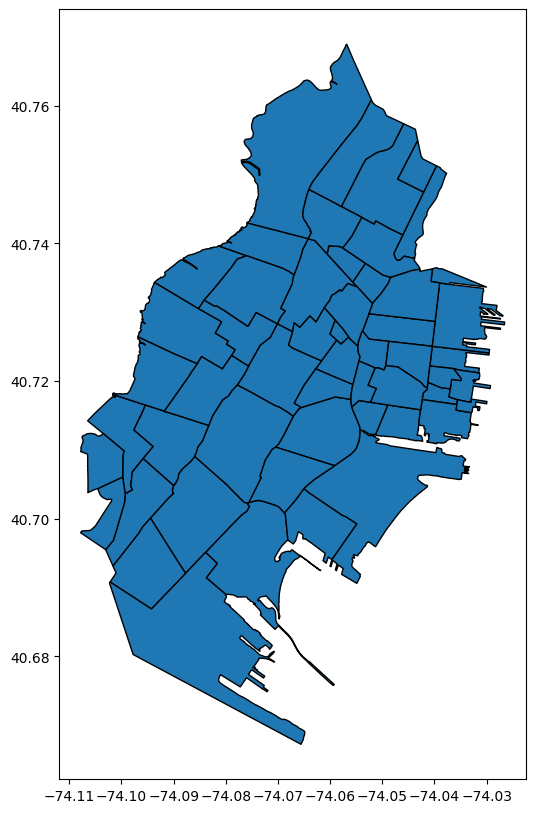

In [14]:
jersey_city.plot(
    figsize=(10, 10),
    edgecolor="black"
)

## Prepare Citi Bike Start Station Data

We extract Citi Bike start station information, including station names
and geographic coordinates.

This dataset will be converted into a GeoDataFrame and used for spatial
analysis with Jersey City neighborhood boundaries.

In [24]:
start_stations = citibike_df[
    [
        "ride_id",
        "start_station_id",
        "start_station_name",
        "start_lat",
        "start_lng"
    ]
].copy()

start_stations.head()

,ride_id,start_station_id,start_station_name,start_lat,start_lng
0,04CF7A399050E404,JC074,Jersey & 3rd,40.723332,-74.045953
1,124AC7493E82D845,JC074,Jersey & 3rd,40.723332,-74.045953
2,1A3BCA838E968327,JC074,Jersey & 3rd,40.723332,-74.045953
3,5994017EE989D6EE,JC074,Jersey & 3rd,40.723332,-74.045953
4,F81BCB97915C6BE6,JC074,Jersey & 3rd,40.723332,-74.045953


## Rename Station Columns and Add Activity Type

We rename the Citi Bike station columns to make them more consistent
for spatial analysis.

We also add an activity type column to identify these records as
departure locations.

In [25]:
start_stations = start_stations.rename(
    columns={
        "start_station_id": "station_id",
        "start_station_name": "station_name",
        "start_lat": "lat",
        "start_lng": "lng"
    }
)

start_stations["activity_type"] = "departure"

## Prepare Citi Bike End Station Data

We extract Citi Bike end station information, including station names
and geographic coordinates.

The activity type column identifies these records as arrival locations,
which will later be combined with departure data for spatial analysis.

In [26]:
end_stations = citibike_df[
    [
        "ride_id",
        "end_station_id",
        "end_station_name",
        "end_lat",
        "end_lng"
    ]
].copy()

end_stations = end_stations.rename(
    columns={
        "end_station_id": "station_id",
        "end_station_name": "station_name",
        "end_lat": "lat",
        "end_lng": "lng"
    }
)

end_stations["activity_type"] = "arrival"

end_stations.head()

,ride_id,station_id,station_name,lat,lng,activity_type
0,04CF7A399050E404,JC035,Van Vorst Park,40.718489,-74.047727,arrival
1,124AC7493E82D845,JC014,Columbus Drive,40.718355,-74.038914,arrival
2,1A3BCA838E968327,JC115,Grove St PATH,40.719410,-74.043090,arrival
3,5994017EE989D6EE,JC074,Jersey & 3rd,40.723332,-74.045953,arrival
4,F81BCB97915C6BE6,HB508,Monroe St & 11 St,40.750109,-74.036637,arrival


## Combine Departure and Arrival Station Activity

We combine departure and arrival station records into a single dataset.

Missing geographic information is removed to ensure that all stations
have valid coordinates for spatial analysis.

In [27]:
station_activity_long = pd.concat(
    [
        start_stations,
        end_stations
    ],
    ignore_index=True
)

station_activity_long = station_activity_long.dropna(
    subset=[
        "station_id",
        "station_name",
        "lat",
        "lng"
    ]
)

station_activity_long.head()

,ride_id,station_id,station_name,lat,lng,activity_type
0,04CF7A399050E404,JC074,Jersey & 3rd,40.723332,-74.045953,departure
1,124AC7493E82D845,JC074,Jersey & 3rd,40.723332,-74.045953,departure
2,1A3BCA838E968327,JC074,Jersey & 3rd,40.723332,-74.045953,departure
3,5994017EE989D6EE,JC074,Jersey & 3rd,40.723332,-74.045953,departure
4,F81BCB97915C6BE6,JC074,Jersey & 3rd,40.723332,-74.045953,departure


## Aggregate Station Activity

We aggregate Citi Bike activity by station and activity type.

The number of rides is calculated separately for departures and arrivals
at each station to understand station usage patterns.

In [28]:
station_activity_agg = (
    station_activity_long
    .groupby(
        [
            "station_id",
            "station_name",
            "lat",
            "lng",
            "activity_type"
        ],
        as_index=False
    )
    .agg(
        number_of_rides=("ride_id", "count")
    )
)

station_activity_agg.head()

,station_id,station_name,lat,lng,activity_type,number_of_rides
0,3278.07,Brooklyn Ave & Snyder Ave,40.649150,-73.943680,arrival,5
1,3344.02,Park Circle & East Dr,40.651566,-73.972212,arrival,5
2,3480.04,Parkside Ave & Flatbush Ave,40.655630,-73.959680,arrival,5
3,3579.04,Windsor Pl & Howard Pl,40.659491,-73.980139,arrival,5
4,3762.08,10 St & 7 Ave,40.666208,-73.981999,arrival,5


## Create Station Activity Summary

We reshape the aggregated station activity data to create a summary
table.

Departure and arrival ride counts are separated into individual columns,
allowing easier comparison of station activity levels.

In [29]:
station_summary = (
    station_activity_agg
    .pivot_table(
        index=[
            "station_id",
            "station_name",
            "lat",
            "lng"
        ],
        columns="activity_type",
        values="number_of_rides",
        fill_value=0
    )
    .reset_index()
)

station_summary.head()

activity_type,station_id,station_name,lat,lng,arrival,departure
0,3278.07,Brooklyn Ave & Snyder Ave,40.649150,-73.943680,5.0,0.0
1,3344.02,Park Circle & East Dr,40.651566,-73.972212,5.0,0.0
2,3480.04,Parkside Ave & Flatbush Ave,40.655630,-73.959680,5.0,0.0
3,3579.04,Windsor Pl & Howard Pl,40.659491,-73.980139,5.0,0.0
4,3762.08,10 St & 7 Ave,40.666208,-73.981999,5.0,0.0


## Calculate Station Activity Metrics

We rename the departure and arrival columns and calculate additional
station-level metrics.

These metrics help identify the most active stations and understand
the balance between outgoing and incoming trips.

In [30]:
station_summary = station_summary.rename(
    columns={
        "departure": "total_departures",
        "arrival": "total_arrivals"
    }
)

station_summary["total_activity"] = (
    station_summary["total_departures"] +
    station_summary["total_arrivals"]
)

station_summary["net_departures"] = (
    station_summary["total_departures"] -
    station_summary["total_arrivals"]
)

station_summary = station_summary.sort_values(
    "total_activity",
    ascending=False
).reset_index(drop=True)

station_summary.head()

activity_type,station_id,station_name,lat,lng,total_arrivals,total_departures,total_activity,net_departures
0,JC115,Grove St PATH,40.719410,-74.043090,224590.0,211940.0,436530.0,-12650.0
1,HB101,Hoboken Terminal - Hudson St & Hudson Pl,40.735938,-74.030305,127520.0,123615.0,251135.0,-3905.0
2,HB106,River St & Newark St,40.736722,-74.029007,110565.0,106915.0,217480.0,-3650.0
3,JC009,Hamilton Park,40.727596,-74.044247,106120.0,105695.0,211815.0,-425.0
4,JC066,Newport PATH,40.727224,-74.033759,97950.0,97770.0,195720.0,-180.0


## Create Geometry Points for Citi Bike Stations

We convert station longitude and latitude coordinates into geographic
Point geometries.

These points will allow us to perform spatial analysis with Jersey City
neighborhood boundaries.

In [31]:
geometry = gpd.points_from_xy(
    station_summary["lng"],
    station_summary["lat"]
)

## Create GeoDataFrame for Citi Bike Stations

We convert the station summary table into a GeoDataFrame by creating
Point geometries from station longitude and latitude coordinates.

The GeoDataFrame will be used for spatial operations with Jersey City
neighborhood boundaries.

In [32]:
station_gdf = gpd.GeoDataFrame(
    station_summary,
    geometry=gpd.points_from_xy(
        station_summary["lng"],
        station_summary["lat"]
    ),
    crs="EPSG:4326"
)

station_gdf.head()

activity_type,station_id,station_name,lat,lng,total_arrivals,total_departures,total_activity,net_departures,geometry
0,JC115,Grove St PATH,40.719410,-74.043090,224590.0,211940.0,436530.0,-12650.0,POINT (-74.04309 40.71941)
1,HB101,Hoboken Terminal - Hudson St & Hudson Pl,40.735938,-74.030305,127520.0,123615.0,251135.0,-3905.0,POINT (-74.0303 40.73594)
2,HB106,River St & Newark St,40.736722,-74.029007,110565.0,106915.0,217480.0,-3650.0,POINT (-74.02901 40.73672)
3,JC009,Hamilton Park,40.727596,-74.044247,106120.0,105695.0,211815.0,-425.0,POINT (-74.04425 40.7276)
4,JC066,Newport PATH,40.727224,-74.033759,97950.0,97770.0,195720.0,-180.0,POINT (-74.03376 40.72722)


## Analyze Popular Citi Bike Routes

We aggregate Citi Bike trips by start and end station pairs to identify
the most frequently used routes.

This analysis helps understand travel patterns and the most common
connections between stations.

In [33]:
route_summary = (
    citibike_df
    .dropna(
        subset=[
            "start_station_id",
            "start_station_name",
            "end_station_id",
            "end_station_name",
            "start_lat",
            "start_lng",
            "end_lat",
            "end_lng"
        ]
    )
    .groupby(
        [
            "start_station_id",
            "start_station_name",
            "end_station_id",
            "end_station_name",
            "start_lat",
            "start_lng",
            "end_lat",
            "end_lng"
        ],
        as_index=False
    )
    .agg(
        number_of_rides=("ride_id", "count")
    )
    .sort_values("number_of_rides", ascending=False)
)

route_summary["route"] = (
    route_summary["start_station_name"] +
    " → " +
    route_summary["end_station_name"]
)

route_summary.head()

,start_station_id,start_station_name,end_station_id,end_station_name,start_lat,start_lng,end_lat,end_lng,number_of_rides,route
81,HB101,Hoboken Terminal - Hudson St & Hudson Pl,JC105,Hoboken Ave at Monmouth St,40.735938,-74.030305,40.735208,-74.046964,21960,Hoboken Terminal - Hudson St & Hudson Pl → Hob...
5462,JC055,McGinley Square,JC109,Bergen Ave & Sip Ave,40.725340,-74.067622,40.731009,-74.064437,20025,McGinley Square → Bergen Ave & Sip Ave
8526,JC115,Grove St PATH,JC013,Marin Light Rail,40.719410,-74.043090,40.714584,-74.042817,19240,Grove St PATH → Marin Light Rail
3834,JC013,Marin Light Rail,JC115,Grove St PATH,40.714584,-74.042817,40.719410,-74.043090,17980,Marin Light Rail → Grove St PATH
8540,JC115,Grove St PATH,JC052,Liberty Light Rail,40.719410,-74.043090,40.711242,-74.055701,17355,Grove St PATH → Liberty Light Rail


## Top 20 Most Popular Routes

We select the 20 most frequently used Citi Bike routes based on the
number of rides.

This provides insight into the most common travel connections between
stations.

In [34]:
top_routes = route_summary.head(20)

top_routes[
    [
        "route",
        "number_of_rides"
    ]
]

,route,number_of_rides
81,Hoboken Terminal - Hudson St & Hudson Pl → Hob...,21960
5462,McGinley Square → Bergen Ave & Sip Ave,20025
8526,Grove St PATH → Marin Light Rail,19240
3834,Marin Light Rail → Grove St PATH,17980
8540,Grove St PATH → Liberty Light Rail,17355
5275,Liberty Light Rail → Grove St PATH,16755
8265,Bergen Ave & Sip Ave → McGinley Square,16680
7978,Hoboken Ave at Monmouth St → Hoboken Terminal ...,15805
4458,Brunswick St → Grove St PATH,14820
3689,Hamilton Park → Grove St PATH,13880


## Visualize Popular Citi Bike Routes

We visualize the most frequently used Citi Bike routes on an interactive
map.

Each line represents a route between two stations, and the line thickness
indicates the number of rides on that route.

In [35]:
import folium

top_lines = route_summary.head(100).copy()

center_lat = station_gdf["lat"].mean()
center_lng = station_gdf["lng"].mean()

line_map = folium.Map(
    location=[center_lat, center_lng],
    zoom_start=12
)

max_rides = top_lines["number_of_rides"].max()

for _, row in top_lines.iterrows():

    start_point = [
        row["start_lat"],
        row["start_lng"]
    ]

    end_point = [
        row["end_lat"],
        row["end_lng"]
    ]

    line_weight = 1 + (row["number_of_rides"] / max_rides) * 8

    folium.PolyLine(
        locations=[start_point, end_point],
        weight=line_weight,
        opacity=0.5,
        popup=f"""
        <b>{row['route']}</b><br>
        Number of Rides: {row['number_of_rides']}
        """
    ).add_to(line_map)

line_map

## Check Coordinate Reference Systems

Before performing spatial operations, we verify that the Citi Bike
station points and neighborhood boundaries use the same Coordinate
Reference System (CRS).

Both datasets must have matching CRS values for accurate spatial joins.

In [36]:
print("Station CRS:", station_gdf.crs)
print("Neighborhood CRS:", jersey_city.crs)

Station CRS: EPSG:4326
Neighborhood CRS: EPSG:4326


## Standardize Coordinate Reference Systems

We convert both the Citi Bike station points and Jersey City
neighborhood boundaries to the same CRS (EPSG:4326).

Using a common CRS ensures accurate spatial joins between station
locations and neighborhood polygons.

In [37]:
station_gdf = station_gdf.to_crs("EPSG:4326")
jersey_city = jersey_city.to_crs("EPSG:4326")

## Inspect Neighborhood Attributes

We review the available columns in the neighborhood dataset to identify
the attributes that can be used for spatial analysis and visualization.

In [38]:
jersey_city.columns

Index(['cartodb_id', 'area_sq_ft', 'acres', 'area', 'neighborhood', 'color',
       'lon', 'lat', 'geometry'],
      dtype='str')

## Assign Stations to Neighborhoods Using Spatial Join

We perform a spatial join between Citi Bike station locations and Jersey
City neighborhood boundaries.

Each station point is assigned to the neighborhood polygon that contains
it.

In [39]:
station_neighborhood = gpd.sjoin(
    station_gdf,
    jersey_city,
    how="inner",
    predicate="within"
)

station_neighborhood.head()

,station_id,station_name,lat_left,lng,total_arrivals,total_departures,total_activity,net_departures,geometry,index_right,cartodb_id,area_sq_ft,acres,area,neighborhood,color,lon,lat_right
0,JC115,Grove St PATH,40.719410,-74.043090,224590.0,211940.0,436530.0,-12650.0,POINT (-74.04309 40.71941),49,2,411601381.8,9449.068,Downtown,Van Vorst Park,21.0,-74.047234,40.718943
3,JC009,Hamilton Park,40.727596,-74.044247,106120.0,105695.0,211815.0,-425.0,POINT (-74.04425 40.7276),10,18,411601381.8,9449.068,Downtown,Hamilton Park,28.0,-74.046672,40.727436
4,JC066,Newport PATH,40.727224,-74.033759,97950.0,97770.0,195720.0,-180.0,POINT (-74.03376 40.72722),8,12,411601381.8,9449.068,Downtown,Newport,22.0,-74.034927,40.729255
5,JC109,Bergen Ave & Sip Ave,40.731009,-74.064437,95340.0,95580.0,190920.0,240.0,POINT (-74.06444 40.73101),16,31,411601381.8,9449.068,Journal Square,Journal Square,NaN,-74.063466,40.733757
6,JC116,Exchange Pl,40.716366,-74.034344,95510.0,95095.0,190605.0,-415.0,POINT (-74.03434 40.71637),48,13,411601381.8,9449.068,Downtown,Exchange Place,23.0,-74.033539,40.716458


## Validate Spatial Join Results

We compare the total number of Citi Bike stations with the number of
stations successfully matched to Jersey City neighborhoods.

This validation step confirms that the spatial join worked correctly.

In [40]:
print("All stations:", len(station_gdf))
print("Stations inside Jersey City neighborhoods:", len(station_neighborhood))

All stations: 480
Stations inside Jersey City neighborhoods: 78


## Analyze Citi Bike Activity by Neighborhood

We aggregate station-level activity to the neighborhood level.

The analysis calculates the number of stations, total departures,
arrivals, and overall bike activity for each neighborhood.

In [41]:
neighborhood_activity = (
    station_neighborhood
    .groupby('neighborhood', as_index=False)
    .agg(
        number_of_stations=("station_id", "nunique"),
        total_departures=("total_departures", "sum"),
        total_arrivals=("total_arrivals", "sum"),
        total_activity=("total_activity", "sum"),
        net_departures=("net_departures", "sum")
    )
)

neighborhood_activity["avg_activity_per_station"] = (
    neighborhood_activity["total_activity"] /
    neighborhood_activity["number_of_stations"]
)

neighborhood_activity = neighborhood_activity.sort_values(
    "total_activity",
    ascending=False
)

neighborhood_activity.head()

,neighborhood,number_of_stations,total_departures,total_arrivals,total_activity,net_departures,avg_activity_per_station
25,Van Vorst Park,6,456325.0,468460.0,924785.0,-12135.0,154130.833333
17,Palus Hook,6,284605.0,282645.0,567250.0,1960.0,94541.666667
14,Newport,2,187070.0,187170.0,374240.0,-100.0,187120.000000
10,Journal Square,3,154990.0,152930.0,307920.0,2060.0,102640.000000
4,Hamilton Park,2,150480.0,151225.0,301705.0,-745.0,150852.500000


## Calculate Map Center Coordinates

We calculate the average latitude and longitude of all Citi Bike stations.

These coordinates will be used to center interactive maps.

In [42]:
center_lat = station_gdf.geometry.y.mean()
center_lng = station_gdf.geometry.x.mean()

center_lat, center_lng

(np.float64(40.734090673586294), np.float64(-74.00151301587097))

## Visualize Citi Bike Stations on Interactive Map

We create an interactive map displaying Citi Bike station locations.

Each station marker contains information about departures, arrivals,
total activity, and net departures.

In [43]:
station_point_map = folium.Map(
    location=[center_lat, center_lng],
    zoom_start=12
)

for _, row in station_gdf.iterrows():

    folium.CircleMarker(
        location=[
            row.geometry.y,
            row.geometry.x
        ],
        radius=5,
        popup=f"""
        <b>{row['station_name']}</b><br>
        Station ID: {row['station_id']}<br>
        Departures: {row['total_departures']:.0f}<br>
        Arrivals: {row['total_arrivals']:.0f}<br>
        Total Activity: {row['total_activity']:.0f}<br>
        Net Departures: {row['net_departures']:.0f}
        """,
        tooltip=row["station_name"],
        fill=True,
        fill_opacity=0.6,
        opacity=0.8
    ).add_to(station_point_map)

station_point_map

## Prepare Neighborhood Choropleth Data

We merge neighborhood boundary geometries with Citi Bike activity metrics.

The resulting GeoDataFrame can be used to create a choropleth map
showing differences in bike activity across neighborhoods.

In [44]:
neighborhood_choropleth_gdf = jersey_city.merge(
    neighborhood_activity,
    on='neighborhood',
    how="left"
)

neighborhood_choropleth_gdf.head()

,cartodb_id,area_sq_ft,acres,area,neighborhood,color,lon,lat,geometry,number_of_stations,total_departures,total_arrivals,total_activity,net_departures,avg_activity_per_station
0,38,411601381.8,9449.068,Greenville,Port Liberte,NaN,-74.074540,40.694202,"POLYGON ((-74.06862 40.70098, -74.06808 40.696...",1.0,60.0,45.0,105.0,15.0,105.000000
1,52,411601381.8,9449.068,Bergen-Lafayette,LSP Industrial,NaN,-74.062358,40.699189,"POLYGON ((-74.06808 40.69684, -74.06862 40.700...",NaN,NaN,NaN,NaN,NaN,NaN
2,29,411601381.8,9449.068,West Side,Hackensack,NaN,-74.085147,40.735520,"POLYGON ((-74.07601 40.73822, -74.07781 40.737...",NaN,NaN,NaN,NaN,NaN,NaN
3,35,411601381.8,9449.068,Bergen-Lafayette,Lafayette,12.0,-74.061279,40.712676,"POLYGON ((-74.056 40.71735, -74.056 40.71692, ...",6.0,148385.0,147795.0,296180.0,590.0,49363.333333
4,51,411601381.8,9449.068,Greenville,Jackson Hill,15.0,-74.085503,40.700791,"POLYGON ((-74.07561 40.70233, -74.0758 40.7020...",16.0,30110.0,29515.0,59625.0,595.0,3726.562500


## Handle Missing Neighborhood Activity Values

Some neighborhoods may not contain Citi Bike stations.
We replace missing activity values with zero so that all neighborhoods
can be included in further analysis and visualization.

In [45]:
activity_columns = [
    "number_of_stations",
    "total_departures",
    "total_arrivals",
    "total_activity",
    "net_departures",
    "avg_activity_per_station"
]

neighborhood_choropleth_gdf[activity_columns] = (
    neighborhood_choropleth_gdf[activity_columns]
    .fillna(0)
)

neighborhood_choropleth_gdf[
    [
        'neighborhood',
        "number_of_stations",
        "total_departures",
        "total_arrivals",
        "total_activity",
        "avg_activity_per_station"
    ]
].head()

,neighborhood,number_of_stations,total_departures,total_arrivals,total_activity,avg_activity_per_station
0,Port Liberte,1.0,60.0,45.0,105.0,105.000000
1,LSP Industrial,0.0,0.0,0.0,0.0,0.000000
2,Hackensack,0.0,0.0,0.0,0.0,0.000000
3,Lafayette,6.0,148385.0,147795.0,296180.0,49363.333333
4,Jackson Hill,16.0,30110.0,29515.0,59625.0,3726.562500


## Create Neighborhood Choropleth Map Function

We create a reusable function to visualize different Citi Bike activity
metrics across Jersey City neighborhoods.

The function allows changing the metric displayed on the map, such as
total activity, departures, arrivals, or station count.

In [46]:
def create_neighborhood_choropleth(
    gdf,
    metric,
    legend_name,
    neighborhood_col="neighborhood"
):
    choropleth_map = folium.Map(
        location=[center_lat, center_lng],
        zoom_start=12
    )

    folium.Choropleth(
        geo_data=gdf,
        data=gdf,
        columns=[neighborhood_col, metric],
        key_on=f"feature.properties.{neighborhood_col}",
        fill_opacity=0.7,
        line_opacity=0.4,
        legend_name=legend_name,
        nan_fill_opacity=0.1
    ).add_to(choropleth_map)

    folium.GeoJson(
        gdf,
        name="Neighborhood Boundaries",
        tooltip=folium.GeoJsonTooltip(
            fields=[
                neighborhood_col,
                metric
            ],
            aliases=[
                "Neighborhood:",
                f"{legend_name}:"
            ],
            localize=True
        ),
        style_function=lambda feature: {
            "fillOpacity": 0,
            "color": "black",
            "weight": 1
        }
    ).add_to(choropleth_map)

    folium.LayerControl().add_to(choropleth_map)

    return choropleth_map

## Visualize Total Citi Bike Activity by Neighborhood

We create a choropleth map showing the total Citi Bike activity across
Jersey City neighborhoods.

Darker areas represent neighborhoods with higher overall station activity.

In [47]:
total_activity_map = create_neighborhood_choropleth(
    gdf=neighborhood_choropleth_gdf,
    metric="total_activity",
    legend_name="Total Citi Bike Activity",
    neighborhood_col="neighborhood"
)

total_activity_map

## Visualize Number of Citi Bike Stations by Neighborhood

We create a choropleth map showing the distribution of Citi Bike
stations across Jersey City neighborhoods.

This helps identify areas with higher station availability.

In [48]:
station_count_map = create_neighborhood_choropleth(
    gdf=neighborhood_choropleth_gdf,
    metric="number_of_stations",
    legend_name="Number of Citi Bike Stations",
    neighborhood_col="neighborhood"
)

station_count_map

## Visualize Average Citi Bike Activity per Station

We create a choropleth map showing the average activity level per Citi
Bike station in each neighborhood.

This metric helps identify neighborhoods where individual stations are
used more intensively.

In [49]:
avg_activity_map = create_neighborhood_choropleth(
    gdf=neighborhood_choropleth_gdf,
    metric="avg_activity_per_station",
    legend_name="Average Activity per Station",
    neighborhood_col="neighborhood"
)

avg_activity_map

## Visualize Total Departures by Neighborhood

We create a choropleth map showing the number of Citi Bike rides that
started in each neighborhood.

This helps identify areas with higher trip origins and possible commuter
departure zones.

In [50]:
departures_map = create_neighborhood_choropleth(
    gdf=neighborhood_choropleth_gdf,
    metric="total_departures",
    legend_name="Total Departures",
    neighborhood_col="neighborhood"
)

departures_map

## Visualize Total Arrivals by Neighborhood

We create a choropleth map showing the number of Citi Bike rides that
ended in each neighborhood.

This helps identify areas that receive more bike trips and possible
destination zones.

In [51]:
arrivals_map = create_neighborhood_choropleth(
    gdf=neighborhood_choropleth_gdf,
    metric="total_arrivals",
    legend_name="Total Arrivals",
    neighborhood_col="neighborhood"
)

arrivals_map